## Cell 1 — Extract Dataset Archives

In [1]:
# ── Cell 1: Extract Dataset Archives ──────────────────────────────────────────
import subprocess

subprocess.run(["unzip", "-q", "-o",
                "BC Images-20260605T061303Z-3-001.zip",
                "-d", "./dataset_images"], check=True)

subprocess.run(["unzip", "-q", "-o",
                "bounding box.zip",
                "-d", "./dataset_annotations"], check=True)

print("✅ Extraction complete!")

✅ Extraction complete!


## Cell 2 — HuggingFace Login & Install Dependencies

In [ ]:


# Uncomment if packages not yet installed:
# !pip install -q timm huggingface_hub pycocotools ipywidgets

from huggingface_hub import login
hf_token = os.environ.get("HF_TOKEN", None)
if hf_token:
    login(token=hf_token)
    print("✅ Logged in via HF_TOKEN")
else:
    print("⚠️  HF_TOKEN not set.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Logged in via HF_TOKEN


## Cell 3 — Imports & Global Config

In [3]:
# ── Cell 3: Imports & Global Config ───────────────────────────────────────────
import gc
import math
import json
import warnings
from pathlib import Path
from collections import OrderedDict
from tqdm import tqdm   # plain console version, not tqdm.notebook
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F_nn
import timm
import torchvision
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader, Subset

from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)

assert torch.cuda.is_available(), "CUDA not available!"
device = torch.device("cuda")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
bf16_ok  = torch.cuda.is_bf16_supported()
print(f"🖥  GPU  : {gpu_name}")
print(f"💾 VRAM : {gpu_mem:.1f} GB")
AMP_DTYPE = torch.bfloat16 if bf16_ok else torch.float16
print(f"🔢 AMP  : {AMP_DTYPE}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE        = 4        # CornerNet heads are memory-heavy; reduce if OOM
NUM_WORKERS       = 4
NUM_EPOCHS        = 30
NUM_CLASSES       = 1          # malignant cell (background handled implicitly)
BASE_LR           = 5e-5       # conservative LR for ViT-Large stability
WEIGHT_DECAY      = 1e-4
WARMUP_STEPS      = 500
GRAD_CLIP         = 1.0
INPUT_SIZE        = 512        # CornerNet canonical input; keep power-of-2
HEATMAP_SIZE = INPUT_SIZE // 16   # = 32 for 512px input  ✅
# was: HEATMAP_SIZE = 128         # ❌ assumes stride-4, but UNI has stride-16SCORE_THRESH      = 0.3        # detection confidence threshold at eval
NMS_THRESH        = 0.5        # IoU threshold for NMS
TEST_SPLIT_RATIO  = 0.2        # fraction of val set used as held-out test set
SAVE_DIR = Path("checkpoint_corner_net")
SAVE_DIR.mkdir(exist_ok=True)

# Paths (same layout as reference notebook)
IMAGE_ROOT = "./dataset_images"
JSON_ROOT  = "./dataset_annotations/bounding box"

print(f"\n⚙️  Config — batch={BATCH_SIZE}, input={INPUT_SIZE}px, epochs={NUM_EPOCHS}, "
      f"test_split={TEST_SPLIT_RATIO}")

🖥  GPU  : NVIDIA H200 NVL
💾 VRAM : 150.1 GB
🔢 AMP  : torch.bfloat16

⚙️  Config — batch=4, input=512px, epochs=30, test_split=0.2


## Cell 4 — Dataset & Val→Val/Test Split

In [4]:
# ── Cell 4: Dataset — CornerNet Gaussian Heatmap Target Generation ──────────
#
# Resilience features preserved from reference notebook:
#   1. rglob path crawler
#   2. .lower() case-insensitive filename matching
#   3. Corrupted-image skip with dynamic fallback
#   4. Empty-box guard
#
# New additions for CornerNet:
#   • Fixed INPUT_SIZE resize + padding to avoid token-count mismatch
#   • Gaussian heatmap generation for TL and BR corners
#   • Offset maps and embedding maps

def gaussian_radius(det_size, min_overlap=0.7):
    """Compute Gaussian radius for a box of given (height, width)."""
    h, w = det_size
    a1 = 1
    b1 = (h + w)
    c1 = w * h * (1 - min_overlap) / (1 + min_overlap)
    sq1 = math.sqrt(b1 ** 2 - 4 * a1 * c1)
    r1 = (b1 - sq1) / (2 * a1)

    a2 = 4
    b2 = 2 * (h + w)
    c2 = (1 - min_overlap) * w * h
    sq2 = math.sqrt(b2 ** 2 - 4 * a2 * c2)
    r2 = (b2 - sq2) / (2 * a2)

    a3 = 4 * min_overlap
    b3 = -2 * min_overlap * (h + w)
    c3 = (min_overlap - 1) * w * h
    sq3 = math.sqrt(max(b3 ** 2 - 4 * a3 * c3, 0))
    r3 = (b3 + sq3) / (2 * a3)

    return max(0, int(min(r1, r2, r3)))


def draw_gaussian(heatmap, center, radius, k=1):
    """Draw a 2D Gaussian blob on heatmap at (cx, cy) with given radius."""
    diameter = 2 * radius + 1
    x = np.arange(0, diameter, 1, np.float32)
    y = x[:, np.newaxis]
    x0 = y0 = diameter // 2
    gaussian = np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * (radius / 3 + 1e-6) ** 2))

    cx, cy = int(center[0]), int(center[1])
    H, W = heatmap.shape

    left,  right = min(cx, radius), min(W - cx, radius + 1)
    top,   bot   = min(cy, radius), min(H - cy, radius + 1)

    masked_hm = heatmap[cy - top : cy + bot, cx - left : cx + right]
    masked_g  = gaussian[y0 - top : y0 + bot, x0 - left : x0 + right]
    np.maximum(masked_hm, masked_g * k, out=masked_hm)


class CornerNetDataset(torchvision.datasets.CocoDetection):
    """COCO-style dataset that returns CornerNet heatmap targets."""

    VALID_EXTS = {".jpg", ".jpeg", ".png"}

    def __init__(self, root_image_dir, annFile, input_size=512, heatmap_size=128):
        super().__init__(root=root_image_dir, annFile=annFile)
        self.input_size   = input_size
        self.heatmap_size = heatmap_size
        self.scale        = heatmap_size / input_size  # 0.25 for stride-4

        # ── [RESILIENCE 1 & 2] Recursive crawler + lowercase mapping ──────────
        self.image_path_mapping = {}
        for fp in Path(root_image_dir).rglob("*.*"):
            if fp.is_file() and fp.suffix.lower() in self.VALID_EXTS:
                self.image_path_mapping[fp.name.lower()] = str(fp)

        valid_ids = [
            iid for iid in self.ids
            if self.coco.loadImgs(iid)[0]["file_name"].lower() in self.image_path_mapping
        ]
        self.ids = valid_ids
        print(f"   📁 {len(valid_ids)} valid images found on disk")

    def __getitem__(self, idx):
        img_id      = self.ids[idx]
        ann_ids     = self.coco.getAnnIds(imgIds=img_id)
        target_anns = self.coco.loadAnns(ann_ids)
        file_name   = self.coco.loadImgs(img_id)[0]["file_name"].lower()
        full_path   = self.image_path_mapping[file_name]

        # ── [RESILIENCE 3] Corrupted-image skip ───────────────────────────────
        try:
            img = Image.open(full_path).convert("RGB")
        except Exception as e:
            print(f"⚠️  Skipping corrupted: {file_name} — {e}")
            return self.__getitem__((idx + 1) % len(self.ids))

        orig_w, orig_h = img.size

        # ── Data Augmentation: Random Horizontal Flip ──
        import copy
        import random
        
        target_anns = copy.deepcopy(target_anns)
        
        if random.random() < 0.5:
            # Flip the PIL image
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            
            # Flip the bounding boxes. 
            # COCO format is [x, y, width, height]. 
            # When flipped, the new top-left x is (width_of_image - old_x - width_of_box)
            for ann in target_anns:
                x, y, w, h = ann['bbox']
                ann['bbox'][0] = orig_w - x - w
        # ── Resize to fixed square (letterbox-pad to preserve aspect ratio) ──
        scale_factor = self.input_size / max(orig_w, orig_h)
        new_w = int(orig_w * scale_factor)
        new_h = int(orig_h * scale_factor)
        img   = img.resize((new_w, new_h), Image.BILINEAR)

        canvas = Image.new("RGB", (self.input_size, self.input_size), (114, 114, 114))
        pad_x = (self.input_size - new_w) // 2
        pad_y = (self.input_size - new_h) // 2
        canvas.paste(img, (pad_x, pad_y))
        img_tensor = F.to_tensor(canvas)   # [3, H, W]

        # ── CornerNet heatmap targets ──────────────────────────────────────────
        S = self.heatmap_size
        tl_hm  = np.zeros((NUM_CLASSES, S, S), dtype=np.float32)
        br_hm  = np.zeros((NUM_CLASSES, S, S), dtype=np.float32)
        tl_off = np.zeros((2, S, S), dtype=np.float32)   # (dx, dy) sub-pixel offset
        br_off = np.zeros((2, S, S), dtype=np.float32)
        tl_mask = np.zeros((S, S), dtype=np.float32)
        br_mask = np.zeros((S, S), dtype=np.float32)
        # Embeddings: tag values for corner grouping (index = object id)
        # We store per-pixel pull targets as object index; ignored outside mask
        tl_tag = np.zeros((S, S), dtype=np.float32)
        br_tag = np.zeros((S, S), dtype=np.float32)

        # ── Also build raw boxes for val/test IoU evaluation ──────────────────
        gt_boxes_abs = []   # in INPUT_SIZE pixel space

        for obj_id, ann in enumerate(target_anns):
            x, y, w, h = ann["bbox"]  # original image coords

            # ── [RESILIENCE 4] Skip degenerate boxes ──────────────────────────
            if w <= 0 or h <= 0:
                continue

            # Remap to padded canvas space
            x1 = x * scale_factor + pad_x
            y1 = y * scale_factor + pad_y
            x2 = (x + w) * scale_factor + pad_x
            y2 = (y + h) * scale_factor + pad_y

            x1 = max(0, min(x1, self.input_size - 1))
            y1 = max(0, min(y1, self.input_size - 1))
            x2 = max(0, min(x2, self.input_size - 1))
            y2 = max(0, min(y2, self.input_size - 1))
            gt_boxes_abs.append([x1, y1, x2, y2])

            # Scale down to heatmap space
            hx1, hy1 = x1 * self.scale, y1 * self.scale
            hx2, hy2 = x2 * self.scale, y2 * self.scale

            hx1_int, hy1_int = int(hx1), int(hy1)
            hx2_int, hy2_int = int(hx2), int(hy2)

            box_h_hm = hy2_int - hy1_int
            box_w_hm = hx2_int - hx1_int
            radius   = gaussian_radius((max(1, box_h_hm), max(1, box_w_hm)))

            cls_idx = 0  # single class: malignant cell
            draw_gaussian(tl_hm[cls_idx], (hx1_int, hy1_int), radius)
            draw_gaussian(br_hm[cls_idx], (hx2_int, hy2_int), radius)

            if 0 <= hy1_int < S and 0 <= hx1_int < S:
                tl_off[0, hy1_int, hx1_int] = hx1 - hx1_int
                tl_off[1, hy1_int, hx1_int] = hy1 - hy1_int
                tl_mask[hy1_int, hx1_int]   = 1.0
                tl_tag[hy1_int, hx1_int]    = obj_id

            if 0 <= hy2_int < S and 0 <= hx2_int < S:
                br_off[0, hy2_int, hx2_int] = hx2 - hx2_int
                br_off[1, hy2_int, hx2_int] = hy2 - hy2_int
                br_mask[hy2_int, hx2_int]   = 1.0
                br_tag[hy2_int, hx2_int]    = obj_id

        if len(gt_boxes_abs) > 0:
            gt_boxes_tensor = torch.tensor(gt_boxes_abs, dtype=torch.float32)
        else:
            gt_boxes_tensor = torch.empty((0, 4), dtype=torch.float32)

        target = {
            "tl_heatmap" : torch.from_numpy(tl_hm),
            "br_heatmap" : torch.from_numpy(br_hm),
            "tl_offset"  : torch.from_numpy(tl_off),
            "br_offset"  : torch.from_numpy(br_off),
            "tl_mask"    : torch.from_numpy(tl_mask),
            "br_mask"    : torch.from_numpy(br_mask),
            "tl_tag"     : torch.from_numpy(tl_tag),
            "br_tag"     : torch.from_numpy(br_tag),
            "gt_boxes"   : gt_boxes_tensor,    # raw boxes for eval
        }
        return img_tensor, target


def collate_fn(batch):
    imgs, targets = zip(*batch)
    return list(imgs), list(targets)

## 
Cell 5 — Build Datasets & Split Val → Val / Test

In [5]:
# ── Cell 5: Build Datasets & Val→Val/Test Split (stratified by box presence) ──
import random

print("Loading train dataset...")
train_dataset = CornerNetDataset(
    root_image_dir = IMAGE_ROOT,
    annFile        = f"{JSON_ROOT}/mcell-detection-train-merged.json",   # ✅ merged + deduped
    input_size     = INPUT_SIZE,
    heatmap_size   = HEATMAP_SIZE,
)

print("\nLoading val dataset (will be split into val + test)...")
full_val_dataset = CornerNetDataset(
    root_image_dir = IMAGE_ROOT,
    annFile        = f"{JSON_ROOT}/mcell-detection-val-merged.json",     # ✅ merged + deduped
    input_size     = INPUT_SIZE,
    heatmap_size   = HEATMAP_SIZE,
)

# ── Stratified 80/20 split: preserve box/no-box ratio in both val and test ───
def get_box_presence_labels(dataset):
    """Returns list of 0/1 per image index: 1 if image has ≥1 box, else 0."""
    labels = []
    for idx in range(len(dataset)):
        img_id = dataset.ids[idx]
        ann_ids = dataset.coco.getAnnIds(imgIds=img_id)
        labels.append(1 if len(ann_ids) > 0 else 0)
    return labels

box_labels = get_box_presence_labels(full_val_dataset)
n_total = len(full_val_dataset)

with_box_indices    = [i for i, lbl in enumerate(box_labels) if lbl == 1]
without_box_indices = [i for i, lbl in enumerate(box_labels) if lbl == 0]

random.seed(42)
random.shuffle(with_box_indices)
random.shuffle(without_box_indices)

n_test_with    = int(len(with_box_indices) * TEST_SPLIT_RATIO)
n_test_without = int(len(without_box_indices) * TEST_SPLIT_RATIO)

test_indices = with_box_indices[:n_test_with] + without_box_indices[:n_test_without]
val_indices  = with_box_indices[n_test_with:] + without_box_indices[n_test_without:]

random.shuffle(val_indices)
random.shuffle(test_indices)

val_dataset  = Subset(full_val_dataset, val_indices)
test_dataset = Subset(full_val_dataset, test_indices)

n_with_box_total = len(with_box_indices)
n_without_box_total = len(without_box_indices)

print(f"\n📊 Dataset split summary (stratified by box presence):")
print(f"   Train : {len(train_dataset):>5} images")
print(f"   Val   : {len(val_dataset):>5} images  "
      f"({n_with_box_total - n_test_with} with-box, {n_without_box_total - n_test_without} no-box)")
print(f"   Test  : {len(test_dataset):>5} images  "
      f"({n_test_with} with-box, {n_test_without} no-box)")
print(f"\n   Pool box-presence ratio : {100*n_with_box_total/n_total:.1f}% with-box / "
      f"{100*n_without_box_total/n_total:.1f}% no-box")
print(f"   (Val and test both preserve this ratio — proportional stratification,")
print(f"    not forced 50/50. Train distribution is left untouched.)")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, persistent_workers=False,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, persistent_workers=False,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, persistent_workers=False,
    collate_fn=collate_fn,
)
print(f"\n✅ DataLoaders ready — "
      f"train: {len(train_loader)} batches | "
      f"val: {len(val_loader)} batches | "
      f"test: {len(test_loader)} batches")

Loading train dataset...
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
   📁 2469 valid images found on disk

Loading val dataset (will be split into val + test)...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
   📁 664 valid images found on disk

📊 Dataset split summary (stratified by box presence):
   Train :  2469 images
   Val   :   532 images  (323 with-box, 209 no-box)
   Test  :   132 images  (80 with-box, 52 no-box)

   Pool box-presence ratio : 60.7% with-box / 39.3% no-box
   (Val and test both preserve this ratio — proportional stratification,
    not forced 50/50. Train distribution is left untouched.)

✅ DataLoaders ready — train: 618 batches | val: 133 batches | test: 33 batches


In [6]:
# ── Cell 5c: Diagnostic — Annotated vs. Unannotated Image Counts (raw COCO files) ──
from pycocotools.coco import COCO
import numpy as np

COCO_ROOT = "./coco"

def count_box_presence_from_json(ann_path, name):
    coco = COCO(ann_path)
    img_ids = coco.getImgIds()

    n_with_boxes = 0
    n_without_boxes = 0
    box_counts = []

    for img_id in img_ids:
        ann_ids = coco.getAnnIds(imgIds=img_id)
        n_boxes = len(ann_ids)
        box_counts.append(n_boxes)
        if n_boxes > 0:
            n_with_boxes += 1
        else:
            n_without_boxes += 1

    total = n_with_boxes + n_without_boxes
    box_counts = np.array(box_counts)

    print(f"─── {name} ───")
    print(f"  Total images        : {total}")
    print(f"  With ≥1 box         : {n_with_boxes:4d}  ({100*n_with_boxes/total:.1f}%)")
    print(f"  With 0 boxes        : {n_without_boxes:4d}  ({100*n_without_boxes/total:.1f}%)")
    print(f"  Mean boxes/image    : {box_counts.mean():.2f}")
    print(f"  Median boxes/image  : {np.median(box_counts):.0f}")
    print(f"  Max boxes/image     : {box_counts.max()}")
    print()
    return n_with_boxes, n_without_boxes, box_counts


print("══════════════════════════════════════════════════════════════")
print("  Box / No-Box Image Counts — Raw COCO Annotation Files")
print("══════════════════════════════════════════════════════════════\n")

train_stats = count_box_presence_from_json(
    f"{COCO_ROOT}/annotations/instances_train2017.json", "TRAIN (instances_train2017.json)"
)
val_stats = count_box_presence_from_json(
    f"{COCO_ROOT}/annotations/instances_val2017.json", "VAL (instances_val2017.json)"
)

print("─── Summary table ───\n")
print(f"{'Split':<35}{'Total':>8}{'With boxes':>14}{'No boxes':>12}{'% no-box':>11}")
for name, stats in [("Train", train_stats), ("Val", val_stats)]:
    n_with, n_without, _ = stats
    total = n_with + n_without
    print(f"{name:<35}{total:>8}{n_with:>14}{n_without:>12}{100*n_without/total:>10.1f}%")

══════════════════════════════════════════════════════════════
  Box / No-Box Image Counts — Raw COCO Annotation Files
══════════════════════════════════════════════════════════════

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
─── TRAIN (instances_train2017.json) ───
  Total images        : 258
  With ≥1 box         :  145  (56.2%)
  With 0 boxes        :  113  (43.8%)
  Mean boxes/image    : 4.58
  Median boxes/image  : 1
  Max boxes/image     : 35

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
─── VAL (instances_val2017.json) ───
  Total images        : 30
  With ≥1 box         :   30  (100.0%)
  With 0 boxes        :    0  (0.0%)
  Mean boxes/image    : 8.60
  Median boxes/image  : 6
  Max boxes/image     : 28

─── Summary table ───

Split                                 Total    With boxes    No boxes   % no-box
Train                                   258           145         113      43.8%
Val            

In [7]:
# ── Cell 5b: Diagnostic — Training Set Cell Density & Annotation Sparsity ──
# Goal: check whether training images give the model enough examples of
# "stained, cell-like, but NOT malignant" regions to learn the distinction.
# We can't judge malignancy ourselves, but we CAN check:
#   1. How many GT boxes per image (sparse vs dense labeling)
#   2. What fraction of image area GT boxes actually cover
#   3. Whether some images have very few/zero boxes despite likely having
#      visible cells (a proxy for "lots of unlabeled-but-visible material")

import numpy as np

def analyze_annotation_density(dataset, name="train"):
    boxes_per_image = []
    box_areas_frac = []   # box area as fraction of full image area
    zero_box_images = 0

    for idx in range(len(dataset)):
        img_id = dataset.ids[idx]
        ann_ids = dataset.coco.getAnnIds(imgIds=img_id)
        anns = dataset.coco.loadAnns(ann_ids)
        n_boxes = len(anns)
        boxes_per_image.append(n_boxes)
        if n_boxes == 0:
            zero_box_images += 1

        img_info = dataset.coco.loadImgs(img_id)[0]
        img_area = img_info["width"] * img_info["height"]
        for ann in anns:
            _, _, w, h = ann["bbox"]
            box_areas_frac.append((w * h) / img_area)

    boxes_per_image = np.array(boxes_per_image)
    box_areas_frac = np.array(box_areas_frac)

    print(f"─── Annotation density: {name} set ({len(dataset)} images) ───\n")
    print(f"  Boxes per image  : mean={boxes_per_image.mean():.2f}  "
          f"median={np.median(boxes_per_image):.0f}  "
          f"min={boxes_per_image.min()}  max={boxes_per_image.max()}")
    print(f"  Images w/ 0 boxes: {zero_box_images} ({100*zero_box_images/len(dataset):.1f}%)")
    print(f"  Images w/ 1 box  : {(boxes_per_image == 1).sum()} "
          f"({100*(boxes_per_image == 1).sum()/len(dataset):.1f}%)")
    print(f"  Images w/ 5+ boxes: {(boxes_per_image >= 5).sum()} "
          f"({100*(boxes_per_image >= 5).sum()/len(dataset):.1f}%)")
    print(f"\n  Avg box area as % of image: {100*box_areas_frac.mean():.3f}%")
    print(f"  Total labeled area is tiny relative to image -> most of every")
    print(f"  image is 'background' by default, including any unlabeled cells.\n")
    return boxes_per_image, box_areas_frac


train_bpi, train_area = analyze_annotation_density(train_dataset, "TRAIN")
print()
val_bpi, val_area = analyze_annotation_density(full_val_dataset, "VAL (full, pre-split)")

─── Annotation density: TRAIN set (2469 images) ───

  Boxes per image  : mean=6.36  median=3  min=0  max=59
  Images w/ 0 boxes: 914 (37.0%)
  Images w/ 1 box  : 130 (5.3%)
  Images w/ 5+ boxes: 1071 (43.4%)

  Avg box area as % of image: 0.842%
  Total labeled area is tiny relative to image -> most of every
  image is 'background' by default, including any unlabeled cells.


─── Annotation density: VAL (full, pre-split) set (664 images) ───

  Boxes per image  : mean=6.25  median=2  min=0  max=53
  Images w/ 0 boxes: 261 (39.3%)
  Images w/ 1 box  : 33 (5.0%)
  Images w/ 5+ boxes: 271 (40.8%)

  Avg box area as % of image: 0.845%
  Total labeled area is tiny relative to image -> most of every
  image is 'background' by default, including any unlabeled cells.



In [8]:
# ── Cell 5e: Merge — Replace Old Annotations with New, Preserve Old Split ──
#
# Strategy:
#   1. Keep the OLD train/val image-level split exactly as-is (2469 / 664).
#   2. For the 263 filenames that exist in BOTH old and new datasets, replace
#      their annotations with the NEW (denser) ones — regardless of which
#      new-split (new train/val) they came from.
#   3. Everything else (the ~2870 non-overlapping old images) is untouched.
#   4. Output: two new merged JSON files, same split structure as old,
#      upgraded annotations where available.

import json
import copy

OLD_TRAIN_JSON = f"{JSON_ROOT}/mcell-detection-train.json"
OLD_VAL_JSON   = f"{JSON_ROOT}/mcell-detection-val.json"
NEW_TRAIN_JSON = "./coco/annotations/instances_train2017.json"
NEW_VAL_JSON   = "./coco/annotations/instances_val2017.json"

MERGED_TRAIN_JSON = f"{JSON_ROOT}/mcell-detection-train-merged.json"
MERGED_VAL_JSON   = f"{JSON_ROOT}/mcell-detection-val-merged.json"

def load_json(path):
    with open(path) as f:
        return json.load(f)

old_train = load_json(OLD_TRAIN_JSON)
old_val   = load_json(OLD_VAL_JSON)
new_train = load_json(NEW_TRAIN_JSON)
new_val   = load_json(NEW_VAL_JSON)

# ── Build a lookup: filename (lowercased) -> list of new annotations + new image info ──
def build_new_lookup(new_json):
    img_by_filename = {img["file_name"].lower(): img for img in new_json["images"]}
    anns_by_img_id = {}
    for ann in new_json["annotations"]:
        anns_by_img_id.setdefault(ann["image_id"], []).append(ann)

    lookup = {}
    for fname, img in img_by_filename.items():
        lookup[fname] = {
            "image_info": img,
            "annotations": anns_by_img_id.get(img["id"], []),
        }
    return lookup

new_lookup = {}
new_lookup.update(build_new_lookup(new_train))
new_lookup.update(build_new_lookup(new_val))   # val entries override if somehow duplicated across new train/val

print(f"New annotation lookup built for {len(new_lookup)} filenames.\n")

# ── Merge function: rebuild one old split's JSON, swapping in new annotations ──
def merge_split(old_json, split_name):
    old_json = copy.deepcopy(old_json)

    next_ann_id = max((a["id"] for a in old_json["annotations"]), default=0) + 1
    new_images = []
    new_annotations = []
    n_replaced = 0
    n_kept_old = 0

    # Keep old annotations indexed by image_id for quick lookup
    old_anns_by_img_id = {}
    for ann in old_json["annotations"]:
        old_anns_by_img_id.setdefault(ann["image_id"], []).append(ann)

    for img in old_json["images"]:
        fname = img["file_name"].lower()
        new_images.append(img)   # image entry itself (id, file_name, width, height) stays from OLD

        if fname in new_lookup:
            # Replace annotations: re-point new annotations to OLD image_id,
            # assign fresh unique annotation IDs to avoid collisions.
            for ann in new_lookup[fname]["annotations"]:
                ann_copy = copy.deepcopy(ann)
                ann_copy["image_id"] = img["id"]      # keep OLD image_id (preserves OLD split structure)
                ann_copy["id"] = next_ann_id
                next_ann_id += 1
                new_annotations.append(ann_copy)
            n_replaced += 1
        else:
            # No new annotation available — keep old annotations for this image unchanged
            new_annotations.extend(old_anns_by_img_id.get(img["id"], []))
            n_kept_old += 1

    merged = {
        "images": new_images,
        "annotations": new_annotations,
        "categories": old_json["categories"],   # already confirmed matching
    }

    print(f"─── {split_name} ───")
    print(f"  Images total          : {len(new_images)}")
    print(f"  Images w/ new annots  : {n_replaced}")
    print(f"  Images w/ old annots  : {n_kept_old}")
    print(f"  Total annotations now : {len(new_annotations)}")
    print()
    return merged

merged_train = merge_split(old_train, "TRAIN (merged)")
merged_val   = merge_split(old_val,   "VAL (merged)")

with open(MERGED_TRAIN_JSON, "w") as f:
    json.dump(merged_train, f)
with open(MERGED_VAL_JSON, "w") as f:
    json.dump(merged_val, f)

print(f"✅ Saved merged annotations:")
print(f"   {MERGED_TRAIN_JSON}")
print(f"   {MERGED_VAL_JSON}")
print(f"\nTotal replaced across both splits: {sum(1 for fn in new_lookup if fn in {img['file_name'].lower() for img in old_train['images']} | {img['file_name'].lower() for img in old_val['images']})}")

New annotation lookup built for 263 filenames.

─── TRAIN (merged) ───
  Images total          : 2469
  Images w/ new annots  : 254
  Images w/ old annots  : 2215
  Total annotations now : 15714

─── VAL (merged) ───
  Images total          : 664
  Images w/ new annots  : 101
  Images w/ old annots  : 563
  Total annotations now : 4152

✅ Saved merged annotations:
   ./dataset_annotations/bounding box/mcell-detection-train-merged.json
   ./dataset_annotations/bounding box/mcell-detection-val-merged.json

Total replaced across both splits: 263


In [9]:
# ── Cell 5f: Check for duplicate filenames across OLD train/val (pre-existing leakage) ──
old_train_fnames = {img["file_name"].lower() for img in old_train["images"]}
old_val_fnames   = {img["file_name"].lower() for img in old_val["images"]}

overlap_old = old_train_fnames & old_val_fnames
print(f"Filenames appearing in BOTH old train and old val: {len(overlap_old)}")
if overlap_old:
    print("Sample:", list(overlap_old)[:10])

# Check whether these overlaps are also in the new-annotation lookup
overlap_old_and_new = overlap_old & set(new_lookup.keys())
print(f"\nOf those, how many also got a 'new annotation' replacement: {len(overlap_old_and_new)}")
print(f"(This explains the 355 vs 263 discrepancy: {len(overlap_old_and_new)} filenames were")
print(f" double-counted — replaced once in train's copy and once in val's copy.)")

Filenames appearing in BOTH old train and old val: 117
Sample: ['p9265986.jpg', 'p9081760.jpg', 'p9265976.jpg', 'p9153397.jpg', 'p9266010.jpg', 'p9265765.jpg', 'p9266004.jpg', 'p9142588.jpg', 'p9153328.jpg', 'p9142548.jpg']

Of those, how many also got a 'new annotation' replacement: 92
(This explains the 355 vs 263 discrepancy: 92 filenames were
 double-counted — replaced once in train's copy and once in val's copy.)


## Cell 6 — Model: UNI Backbone + FPN Neck + CornerNet Head

In [10]:
# ── Cell 6: UNI Backbone (multi-level feature extraction) ─────────────────────
#
# UNI is a ViT-Large (patch=16, dim=1024). It has no native FPN,
# so we tap intermediate layers to build a 4-level pyramid:
#   • Stage indices [6, 12, 18, 23] (out of 24 blocks) → P3, P4, P5, P6
# Each stage output is [B, N, 1024] → reshaped to [B, 1024, H/16, W/16]
# FPN then projects all to 256 channels with lateral connections.

class UNIMultiScaleBackbone(nn.Module):
    """
    UNI ViT-Large backbone returning 4 intermediate feature maps
    at ViT stages [6, 12, 18, 23], all at the same spatial resolution
    (H/16, W/16) but semantically richer at deeper stages.
    FPN handles multi-scale fusion.
    """
    STAGE_INDICES = [5, 11, 17, 23]   # 0-indexed block indices

    def __init__(self):
        super().__init__()
        self.vit = timm.create_model(
            "hf-hub:MahmoodLab/UNI",
            pretrained=True,
            init_values=1e-5,
            dynamic_img_size=True,
            num_classes=0,
        )
        # Fine-tune all parameters
        for p in self.vit.parameters():
            p.requires_grad = True

        self.dim = 1024   # ViT-Large hidden dim

    def _tokens_to_map(self, tokens, x):       # parameter renamed x (not x_shape)
        B, N, D = tokens.shape
        Hf = x.shape[-2] // 16                 # x.shape[-2] is an int ✅
        Wf = x.shape[-1] // 16                 # x.shape[-1] is an int ✅
        assert N == Hf * Wf, (
            f"Token mismatch: {N} tokens vs {Hf}×{Wf}={Hf*Wf} expected. "
            "Ensure INPUT_SIZE is divisible by 16."
        )
        return tokens.transpose(1, 2).contiguous().reshape(B, D, Hf, Wf)
        
    def forward(self, x):
        """
        Returns OrderedDict with keys '0'–'3' (P3–P6 before FPN lateral merge),
        each [B, 1024, H/16, W/16].
        """
        # Run ViT patch embed + positional encoding
        tokens = self.vit.patch_embed(x)                         # [B, N, D]
        tokens = self.vit._pos_embed(tokens)                     # + pos embed
        tokens = self.vit.patch_drop(tokens)
        tokens = self.vit.norm_pre(tokens)

        outputs = OrderedDict()
        stage_set = set(self.STAGE_INDICES)
        out_idx = 0

        for blk_idx, blk in enumerate(self.vit.blocks):
            tokens = blk(tokens)
            if blk_idx in stage_set:
                # Strip CLS token (first position)
                patch_tokens = tokens[:, 1:, :]
                outputs[str(out_idx)] = self._tokens_to_map(patch_tokens, x)
                out_idx += 1

        return outputs   # {'0': P3_raw, '1': P4_raw, '2': P5_raw, '3': P6_raw}

In [11]:
# ── Cell 6b: FPN Neck ──────────────────────────────────────────────────────────
#
# Standard FPN: 4 lateral 1×1 convs (1024→256) + top-down pathway
# with nearest-neighbour upsample + element-wise add.
# All four output levels share the same spatial resolution (H/16, W/16)
# because UNI does not natively downsample. We therefore apply optional
# downsampling strides to create true multi-scale P3–P6.
# P3 = stride-1 (kept at H/16)  → for small cells
# P4 = stride-2 (→ H/32)
# P5 = stride-4 (→ H/64)
# P6 = stride-8 (→ H/128)

class FPN(nn.Module):
    def __init__(self, in_channels=1024, out_channels=256, num_levels=4):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            for _ in range(num_levels)
        ])
        self.output_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in range(num_levels)
        ])
        # Stride-2 pools to create true spatial hierarchy from UNI's flat features
        self.downsamples = nn.ModuleList([
            nn.Identity(),                                         # P3: H/16
            nn.MaxPool2d(kernel_size=2, stride=2),                 # P4: H/32
            nn.MaxPool2d(kernel_size=4, stride=4),                 # P5: H/64
            nn.MaxPool2d(kernel_size=8, stride=8),                 # P6: H/128
        ])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, a=1)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, features: OrderedDict):
        """
        features: OrderedDict {'0'–'3'} from backbone, each [B, 1024, Hf, Wf]
        Returns list of 4 tensors [B, 256, Hf/s, Wf/s] for P3–P6.
        """
        # Step 1: lateral projections + spatial downsampling
        laterals = []
        for i, key in enumerate(features):
            lat = self.lateral_convs[i](features[key])
            lat = self.downsamples[i](lat)
            laterals.append(lat)

        # Step 2: top-down fusion (deepest level first, upsample to match shallower)
        # laterals[3]=P6 (smallest), laterals[0]=P3 (largest)
        for i in range(len(laterals) - 1, 0, -1):
            laterals[i - 1] = laterals[i - 1] + F_nn.interpolate(
                laterals[i],
                size=laterals[i - 1].shape[-2:],
                mode="nearest",
            )

        # Step 3: output 3×3 conv
        outs = [self.output_convs[i](laterals[i]) for i in range(len(laterals))]
        return outs   # [P3, P4, P5, P6]

In [12]:
# ── Cell 6c: CornerNet Head ────────────────────────────────────────────────────
#
# CornerNet predicts per-corner heatmaps, offsets, and embedding tags.
# We operate on P3 (highest resolution FPN level, stride-1 relative to
# the 512×512 input → 32×32 after UNI's patch-16 stride)
# which gives HEATMAP_SIZE = INPUT_SIZE // 16 = 32 for 512px input.
#
# NOTE: We set HEATMAP_SIZE = INPUT_SIZE // 16 (not //4) because UNI
# has patch stride 16. Update the config constant if needed.

class CornerHeadBranch(nn.Module):
    """Shared structure for TL and BR branches."""
    def __init__(self, in_channels=256, num_classes=1, tag_dim=1):
        super().__init__()
        self.heatmap = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1),
        )
        self.offset = nn.Sequential(
            nn.Conv2d(in_channels, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 2, 1),      # dx, dy
        )
        self.embedding = nn.Sequential(
            nn.Conv2d(in_channels, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, tag_dim, 1),  # associative embedding tag
        )
        # Bias init: focal-loss friendly (rare positive initialisation)
        nn.init.constant_(self.heatmap[-1].bias, -2.19)

    def forward(self, x):
        return (
            self.heatmap(x),    # [B, C, H, W]
            self.offset(x),     # [B, 2, H, W]
            self.embedding(x),  # [B, tag_dim, H, W]
        )


class CornerNetHead(nn.Module):
    """Two-branch head: top-left + bottom-right corners."""
    def __init__(self, in_channels=256, num_classes=1, tag_dim=8):
        super().__init__()
        self.tl = CornerHeadBranch(in_channels, num_classes, tag_dim=tag_dim)
        self.br = CornerHeadBranch(in_channels, num_classes, tag_dim=tag_dim)

    def forward(self, fpn_p3):
        tl_hm, tl_off, tl_emb = self.tl(fpn_p3)
        br_hm, br_off, br_emb = self.br(fpn_p3)
        return {
            "tl_hm" : tl_hm,
            "br_hm" : br_hm,
            "tl_off": tl_off,
            "br_off": br_off,
            "tl_emb": tl_emb,
            "br_emb": br_emb,
        }

In [13]:
# ── Cell 6d: Full Model Assembly ───────────────────────────────────────────────
class MalignantCellDetector(nn.Module):
    def __init__(self, num_classes=1, tag_dim=8):
        super().__init__()
        self.backbone = UNIMultiScaleBackbone()
        self.fpn      = FPN(in_channels=1024, out_channels=256, num_levels=4)
        self.head     = CornerNetHead(in_channels=256, num_classes=num_classes, tag_dim=tag_dim)
    def forward(self, images):
        """
        images: list of [3, H, W] tensors  (H=W=INPUT_SIZE)
        Returns head output dict.
        """
        x       = torch.stack(images)           # [B, 3, H, W]
        feats   = self.backbone(x)              # OrderedDict of 4 maps
        fpn_out = self.fpn(feats)               # list of [B, 256, ...]  P3–P6
        out     = self.head(fpn_out[0])         # use P3 (highest-res) for corners
        return out


model = MalignantCellDetector(num_classes=NUM_CLASSES, tag_dim=8).to(device)
model = torch.compile(model)   # 🔧 fuses kernels, often 1.3–2x speedup on H100/H200-class GPUs
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model assembled")
print(f"   Total     : {total_params/1e6:.1f} M params")
print(f"   Trainable : {trainable_params/1e6:.1f} M params")

✅ Model assembled
   Total     : 309.1 M params
   Trainable : 309.1 M params


## Cell 7 — Loss Functions (Focal + Offset + Push-Pull Embedding)

In [23]:
# ── Cell 7: CornerNet Loss Functions ──────────────────────────────────────────
#
# 1. Focal Loss (heatmap)  — modified focal loss from CornerNet paper
# 2. Smooth L1 / L1 Loss  — for offset regression at corner locations
# 3. Push-Pull Loss        — for associative embeddings (group TL/BR pairs)

def focal_loss_cornernet(pred, gt, alpha=2, beta=4):
    """
    CornerNet modified focal loss.
    pred: [B, C, H, W] raw logits → sigmoid applied inside
    gt  : [B, C, H, W] Gaussian heatmap targets in [0, 1]
    """
    pred = torch.sigmoid(pred)
    pos_mask = (gt == 1).float()
    neg_mask = (gt < 1).float()

    neg_weights = (1 - gt) ** beta

    pos_loss = -((1 - pred) ** alpha) * torch.log(pred + 1e-6) * pos_mask
    neg_loss = -(neg_weights * (pred ** alpha) * torch.log(1 - pred + 1e-6) * neg_mask)

    n_pos = pos_mask.sum().clamp(min=1)
    return (pos_loss.sum() + neg_loss.sum()) / n_pos


def offset_loss(pred_off, gt_off, mask):
    """
    Smooth L1 loss for corner offsets, computed only at positive corner locations.
    pred_off: [B, 2, H, W]
    gt_off  : [B, 2, H, W]
    mask    : [B, H, W]   (1 at corner positions)
    """
    mask2 = mask.unsqueeze(1).expand_as(pred_off)  # [B, 2, H, W]
    n = mask2.sum().clamp(min=1)
    return F_nn.smooth_l1_loss(pred_off * mask2, gt_off * mask2, reduction="sum") / n

def push_pull_loss(tl_emb, br_emb, tl_mask, br_mask, tl_tag, br_tag, margin=3.0):
    pull_loss = torch.tensor(0.0, device=tl_emb.device)
    push_loss = torch.tensor(0.0, device=tl_emb.device)
    batch_size = tl_emb.size(0)

    for b in range(batch_size):
        tl_pos = (tl_mask[b] > 0).nonzero(as_tuple=False)
        br_pos = (br_mask[b] > 0).nonzero(as_tuple=False)
        if tl_pos.numel() == 0 or br_pos.numel() == 0:
            continue

        tl_e = tl_emb[b, :, tl_pos[:, 0], tl_pos[:, 1]].T   # [N_tl, tag_dim]
        br_e = br_emb[b, :, br_pos[:, 0], br_pos[:, 1]].T   # [N_br, tag_dim]
        tl_t = tl_tag[b, tl_pos[:, 0], tl_pos[:, 1]]
        br_t = br_tag[b, br_pos[:, 0], br_pos[:, 1]]

        all_e = torch.cat([tl_e, br_e], dim=0)   # [N, tag_dim]
        all_t = torch.cat([tl_t, br_t])

        unique_ids, idx = torch.unique(all_t, return_inverse=True)
        n_obj = len(unique_ids)
        if n_obj == 0:
            continue

        means = torch.zeros(n_obj, all_e.size(1), device=tl_emb.device, dtype=all_e.dtype)
        counts = torch.zeros(n_obj, 1, device=tl_emb.device, dtype=all_e.dtype)
        means.scatter_add_(0, idx.unsqueeze(1).expand(-1, all_e.size(1)), all_e)
        counts.scatter_add_(0, idx.unsqueeze(1), torch.ones(idx.size(0), 1, device=tl_emb.device, dtype=all_e.dtype))
        means = means / counts.clamp(min=1)

        pull_loss = pull_loss + ((all_e - means[idx]) ** 2).sum(dim=1).mean()

        if n_obj > 1:
            dist = torch.cdist(means, means)
            eye  = torch.eye(n_obj, device=tl_emb.device, dtype=means.dtype)
            push = F_nn.relu(margin - dist) * (1 - eye)
            push_loss = push_loss + push.sum() / ((1 - eye).sum() + 1e-6)

    return pull_loss / batch_size, push_loss / batch_size

def compute_total_loss(preds, targets, device,
                       w_hm=1.0, w_off=1.0, w_pull=1.0, w_push=1.0):
    """
    Combine all CornerNet loss components.
    Returns total scalar loss and a dict of individual losses for logging.
    """
    tl_hm_gt  = torch.stack([t["tl_heatmap"] for t in targets]).to(device)
    br_hm_gt  = torch.stack([t["br_heatmap"] for t in targets]).to(device)
    tl_off_gt = torch.stack([t["tl_offset"]  for t in targets]).to(device)
    br_off_gt = torch.stack([t["br_offset"]  for t in targets]).to(device)
    tl_mask   = torch.stack([t["tl_mask"]    for t in targets]).to(device)
    br_mask   = torch.stack([t["br_mask"]    for t in targets]).to(device)
    tl_tag_gt = torch.stack([t["tl_tag"]     for t in targets]).to(device)
    br_tag_gt = torch.stack([t["br_tag"]     for t in targets]).to(device)

    loss_tl_hm  = focal_loss_cornernet(preds["tl_hm"], tl_hm_gt)
    loss_br_hm  = focal_loss_cornernet(preds["br_hm"], br_hm_gt)
    loss_tl_off = offset_loss(preds["tl_off"], tl_off_gt, tl_mask)
    loss_br_off = offset_loss(preds["br_off"], br_off_gt, br_mask)
    loss_pull, loss_push = push_pull_loss(
        preds["tl_emb"], preds["br_emb"],
        tl_mask, br_mask,
        tl_tag_gt, br_tag_gt
    )

    total = (w_hm  * (loss_tl_hm + loss_br_hm) +
             w_off * (loss_tl_off + loss_br_off) +
             w_pull * loss_pull +
             w_push * loss_push)

    loss_dict = {
        "tl_heatmap": loss_tl_hm.item(),
        "br_heatmap": loss_br_hm.item(),
        "tl_offset" : loss_tl_off.item(),
        "br_offset" : loss_br_off.item(),
        "pull"      : loss_pull.item(),
        "push"      : loss_push.item(),
        "total"     : total.item(),
    }
    return total, loss_dict

print("✅ Loss functions defined.")

✅ Loss functions defined.


## Cell 8 — Optimizer, Scheduler & AMP Scaler

In [14]:
# ── Cell 8: Optimizer, Scheduler & AMP Scaler ─────────────────────────────────

# Separate LR groups: lower LR for large pretrained backbone
param_groups = [
    {"params": model.backbone.parameters(), "lr": BASE_LR * 0.1},   # ViT-Large
    {"params": model.fpn.parameters(),      "lr": BASE_LR},
    {"params": model.head.parameters(),     "lr": BASE_LR},
]

optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay = WEIGHT_DECAY,
    fused        = True,
)

total_steps = NUM_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda", enabled=(AMP_DTYPE == torch.float16))

print(f"✅ Optimizer: AdamW (backbone LR×0.1={BASE_LR*0.1:.1e}, head LR={BASE_LR:.1e})")
print(f"   Scheduler: cosine+warmup ({WARMUP_STEPS} steps over {total_steps} total)")
print(f"   AMP dtype: {AMP_DTYPE} | GradScaler enabled: {scaler.is_enabled()}")

✅ Optimizer: AdamW (backbone LR×0.1=5.0e-06, head LR=5.0e-05)
   Scheduler: cosine+warmup (500 steps over 18540 total)
   AMP dtype: torch.bfloat16 | GradScaler enabled: False


## Cell 9 — Sanity Check (Single Forward + Loss Pass)

In [16]:
# ── Cell 9: Sanity Check ──────────────────────────────────────────────────────
print("Running sanity check...")

model.train()
sample_imgs, sample_targets = next(iter(train_loader))
sample_imgs_gpu = [img.to(device, non_blocking=True) for img in sample_imgs]

with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
    preds = model(sample_imgs_gpu)
    loss, loss_dict = compute_total_loss(preds, sample_targets, device)

print(f"✅ Forward pass OK")
print(f"   Input shape : {sample_imgs_gpu[0].shape}")
print(f"   TL heatmap  : {preds['tl_hm'].shape}")
print(f"   BR heatmap  : {preds['br_hm'].shape}")
print(f"   Offset shape: {preds['tl_off'].shape}")
print("   Losses:")
for k, v in loss_dict.items():
    print(f"     {k:<15s}: {v:.4f}")

del sample_imgs, sample_targets, sample_imgs_gpu, preds, loss
gc.collect()
torch.cuda.empty_cache()
print("🧹 Cleanup complete.")

Running sanity check...
✅ Forward pass OK
   Input shape : torch.Size([3, 512, 512])
   TL heatmap  : torch.Size([4, 1, 32, 32])
   BR heatmap  : torch.Size([4, 1, 32, 32])
   Offset shape: torch.Size([4, 2, 32, 32])
   Losses:
     tl_heatmap     : 2.0737
     br_heatmap     : 1.8825
     tl_offset      : 0.2070
     br_offset      : 0.1471
     pull           : 0.0946
     push           : 1.4083
     total          : 5.8132
🧹 Cleanup complete.


## Cell 10 — Training Loop

In [ ]:
# ── Cell 10: Training Loop ─────────────────────────────────────────────────────

best_val_loss = float("inf")
global_step   = 0
history       = []          # list of dicts for post-training analysis

for epoch in range(NUM_EPOCHS):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{NUM_EPOCHS} [train]", leave=False)

    for imgs, targets in train_bar:
        imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
            preds = model(imgs_gpu)
            loss, loss_dict = compute_total_loss(preds, targets, device)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        global_step      += 1
        epoch_train_loss += loss.item()
        train_bar.set_postfix(
            loss  = f"{loss.item():.4f}",
            tl_hm = f"{loss_dict['tl_heatmap']:.3f}",
            pull  = f"{loss_dict['pull']:.3f}",
            push  = f"{loss_dict['push']:.3f}",
            lr    = f"{scheduler.get_last_lr()[0]:.1e}",
        )

    avg_train_loss = epoch_train_loss / len(train_loader)

    # ── VALIDATE (loss only — no eval decode during training for speed) ────────
    model.eval()
    epoch_val_loss = 0.0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:>2}/{NUM_EPOCHS} [val  ]", leave=False)

    with torch.no_grad():
        for imgs, targets in val_bar:
            imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]
            with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
                preds = model(imgs_gpu)
                loss, _ = compute_total_loss(preds, targets, device)
            epoch_val_loss += loss.item()
            val_bar.set_postfix(val_loss=f"{loss.item():.4f}")

    avg_val_loss = epoch_val_loss / len(val_loader)

    row = {"epoch": epoch + 1, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
           "lr": scheduler.get_last_lr()[0]}
    history.append(row)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | "
          f"train={avg_train_loss:.4f} | "
          f"val={avg_val_loss:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    # ── Checkpointing ──────────────────────────────────────────────────────────
    ckpt = {
        "epoch"    : epoch + 1,
        "model"    : model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "val_loss" : avg_val_loss,
    }
    torch.save(ckpt, SAVE_DIR / "checkpoint_latest.pt")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(ckpt, SAVE_DIR / "checkpoint_best.pt")
        print(f"   ✅ New best val loss: {best_val_loss:.4f} → checkpoint_best.pt")

print(f"\n🏁 Training complete. Best val loss: {best_val_loss:.4f}")

Epoch  1/30 | train=3.7947 | val=2.0887 | lr=5.00e-06
   ✅ New best val loss: 2.0887 → checkpoint_best.pt


Epoch  2/30 | train=1.8388 | val=1.7412 | lr=4.98e-06
   ✅ New best val loss: 1.7412 → checkpoint_best.pt


Epoch  3/30 | train=1.4980 | val=1.4461 | lr=4.93e-06
   ✅ New best val loss: 1.4461 → checkpoint_best.pt


Epoch  4/30 | train=1.2746 | val=1.3251 | lr=4.85e-06
   ✅ New best val loss: 1.3251 → checkpoint_best.pt


Epoch  5/30 | train=1.1584 | val=1.2802 | lr=4.75e-06
   ✅ New best val loss: 1.2802 → checkpoint_best.pt


...

Epoch 26/30 | train=0.0482 | val=3.6660 | lr=2.28e-07


Epoch 27/30 | train=0.0439 | val=3.7109 | lr=1.29e-07


Epoch 28/30 | train=0.0443 | val=3.7636 | lr=5.77e-08


Epoch 29/30 | train=0.0420 | val=3.6843 | lr=1.45e-08


Epoch 30/30 [train]:  46%|▍| 285/618 [00:44<00:50,  6.62it/s, loss=0.0222, lr=4.2e-09, pull=0.006, push=0.002, tl_hm=0.

## Cell 11 — CornerNet Decoder (Heatmap → Boxes)

In [15]:
# ── Cell 11: CornerNet Decoder ─────────────────────────────────────────────────
#
# Steps:
# 1. Sigmoid → peak extraction (local max pool NMS on heatmap)
# 2. Select top-K TL and BR corners
# 3. Add sub-pixel offset
# 4. Pair TL/BR by embedding distance (greedy nearest-neighbour)
# 5. Filter by pairing distance threshold → return boxes + scores

def heatmap_nms(hm, kernel=3):
    """Suppress non-local-maxima using max-pool."""
    pad  = (kernel - 1) // 2
    hmax = F_nn.max_pool2d(hm, kernel_size=kernel, stride=1, padding=pad)
    keep = (hm == hmax).float()
    return hm * keep


def topk(scores, K=100):
    """Return top-K positions and scores from [B, C, H, W]."""
    B, C, H, W = scores.shape
    scores_flat = scores.view(B, C, -1)
    topk_scores, topk_inds = torch.topk(scores_flat, min(K, H * W))
    topk_ys = (topk_inds // W).float()
    topk_xs = (topk_inds %  W).float()
    return topk_scores, topk_inds, topk_ys, topk_xs

SCORE_THRESH = 0.1       # ✅ low enough to see detections early in training
NMS_THRESH   = 0.3
INPUT_SIZE   = 512   

def decode_cornernet(preds, K=100, ae_threshold=1.0,
                     score_threshold=SCORE_THRESH,
                     nms_threshold=NMS_THRESH,
                     input_size=INPUT_SIZE):
    """
    Decode CornerNet predictions into bounding boxes.

    Returns list of dicts (one per image):
      {"boxes": [N,4] in input_size coords, "scores": [N]}
    """
    tl_hm  = torch.sigmoid(preds["tl_hm"])       # [B, C, Hm, Wm]
    br_hm  = torch.sigmoid(preds["br_hm"])
    tl_off = preds["tl_off"]                      # [B, 2, Hm, Wm]
    br_off = preds["br_off"]
    tl_emb = preds["tl_emb"]           # [B, Hm, Wm]
    br_emb = preds["br_emb"]
    B, C, Hm, Wm = tl_hm.shape
    stride_h = input_size / Hm   # e.g. 512/32 = 16
    stride_w = input_size / Wm# e.g. 512/32 = 16

    tl_hm = heatmap_nms(tl_hm)
    br_hm = heatmap_nms(br_hm)

    tl_scores, tl_inds, tl_ys, tl_xs = topk(tl_hm, K)
    br_scores, br_inds, br_ys, br_xs = topk(br_hm, K)

    # Flatten to [B, K]
    tl_scores = tl_scores.view(B, -1)
    br_scores = br_scores.view(B, -1)
    tl_ys     = tl_ys.view(B, -1)
    tl_xs     = tl_xs.view(B, -1)
    br_ys     = br_ys.view(B, -1)
    br_xs     = br_xs.view(B, -1)

        # Gather offsets at detected positions
    def gather_offset(off, ys, xs):
        """off: [B, 2, H, W], ys/xs: [B, K] int indices."""
        B_, K_ = ys.shape
        ys_int = ys.long().clamp(0, Hm - 1)
        xs_int = xs.long().clamp(0, Wm - 1)
        flat_idx = ys_int * Wm + xs_int  # [B, K], flattened H*W index
        return off[:, 0].view(B_, -1).gather(1, flat_idx), \
               off[:, 1].view(B_, -1).gather(1, flat_idx)
        
    tl_off_x, tl_off_y = gather_offset(tl_off, tl_ys, tl_xs)
    br_off_x, br_off_y = gather_offset(br_off, br_ys, br_xs)

    # Exact sub-pixel positions in heatmap space
    # Exact sub-pixel positions in heatmap space
    tl_x_f = (tl_xs + tl_off_x) * stride_w
    tl_y_f = (tl_ys + tl_off_y) * stride_h
    br_x_f = (br_xs + br_off_x) * stride_w
    br_y_f = (br_ys + br_off_y) * stride_h

    # Gather embeddings
    def gather_emb(emb, ys, xs):
            """emb: [B, tag_dim, H, W], ys/xs: [B, K] -> returns [B, K, tag_dim]"""
            B_, K_ = ys.shape
            tag_dim = emb.size(1)
            ys_int = ys.long().clamp(0, Hm - 1)
            xs_int = xs.long().clamp(0, Wm - 1)
            flat_idx = (ys_int * Wm + xs_int).unsqueeze(1).expand(-1, tag_dim, -1)  # [B, tag_dim, K]
            gathered = emb.view(B_, tag_dim, -1).gather(2, flat_idx)               # [B, tag_dim, K]
            return gathered.permute(0, 2, 1)  # [B, K, tag_dim]

    tl_emb_v = gather_emb(tl_emb, tl_ys, tl_xs)  # [B, K]
    br_emb_v = gather_emb(br_emb, br_ys, br_xs)  # [B, K]

    results = []
    for b in range(B):
        boxes_out  = []
        scores_out = []

        # Pair TL/BR corners greedily by smallest embedding distance
        # tl_emb_v[b]: [K_tl],  br_emb_v[b]: [K_br]
        dist_mat = torch.cdist(tl_emb_v[b], br_emb_v[b])  # [K_tl, K_br], L2 distance
        ae_dist, paired_br = dist_mat.min(dim=1)  # [K_tl]

        for tl_i in range(tl_scores.shape[1]):
            tl_s = tl_scores[b, tl_i].item()
            if tl_s < score_threshold:
                break  # sorted descending; rest will be lower

            if ae_dist[tl_i] > ae_threshold:
                continue

            br_i = paired_br[tl_i].item()
            br_s = br_scores[b, br_i].item()

            x1 = tl_x_f[b, tl_i].item()
            y1 = tl_y_f[b, tl_i].item()
            x2 = br_x_f[b, br_i].item()
            y2 = br_y_f[b, br_i].item()

            if x2 <= x1 or y2 <= y1:
                continue

            score = (tl_s + br_s) / 2.0
            if score < score_threshold:
                continue

            boxes_out.append([x1, y1, x2, y2])
            scores_out.append(score)

        if len(boxes_out) > 0:
            boxes_t  = torch.tensor(boxes_out,  dtype=torch.float32)
            scores_t = torch.tensor(scores_out, dtype=torch.float32)
            # Soft-NMS via torchvision
            keep = torchvision.ops.nms(boxes_t, scores_t, nms_threshold)
            boxes_t  = boxes_t[keep]
            scores_t = scores_t[keep]
        else:
            boxes_t  = torch.empty((0, 4), dtype=torch.float32)
            scores_t = torch.empty((0,),   dtype=torch.float32)

        results.append({"boxes": boxes_t, "scores": scores_t})

    return results

print("✅ Decoder defined.")

✅ Decoder defined.


## Cell 12 — IoU / Precision / Recall / AP Evaluation on Test Set

In [16]:
# ── Cell 12: IoU / Precision / Recall / AP@0.5 Evaluation ─────────────────────

def box_iou_matrix(boxes_a, boxes_b):
    """
    Compute pairwise IoU between two sets of boxes.
    boxes_a: [M, 4], boxes_b: [N, 4]  (x1,y1,x2,y2)
    Returns [M, N] IoU matrix.
    """
    area_a = (boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])  # [M]
    area_b = (boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])  # [N]

    inter_x1 = torch.max(boxes_a[:, 0].unsqueeze(1), boxes_b[:, 0].unsqueeze(0))  # [M, N]
    inter_y1 = torch.max(boxes_a[:, 1].unsqueeze(1), boxes_b[:, 1].unsqueeze(0))
    inter_x2 = torch.min(boxes_a[:, 2].unsqueeze(1), boxes_b[:, 2].unsqueeze(0))
    inter_y2 = torch.min(boxes_a[:, 3].unsqueeze(1), boxes_b[:, 3].unsqueeze(0))

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter   = inter_w * inter_h  # [M, N]

    union = area_a.unsqueeze(1) + area_b.unsqueeze(0) - inter
    return inter / union.clamp(min=1e-6)


def evaluate_on_loader(model, loader, device,
                       iou_threshold=0.5,
                       score_threshold=SCORE_THRESH):
    """
    Runs decoder on every batch in loader and computes:
    - Mean IoU (over matched detections)
    - Precision@IoU_threshold
    - Recall@IoU_threshold
    - AP@IoU_threshold (area under precision-recall curve)

    Returns dict with all metrics.
    """
    model.eval()

    all_scores  = []   # flat list of detection scores
    all_tp      = []   # bool: is this detection a TP at iou_threshold?
    total_gt    = 0    # total ground-truth boxes across all images
    matched_ious = []  # IoU of each TP match

    with torch.no_grad():
        bar = tqdm(loader, desc="Evaluating", leave=True)
        for imgs, targets in bar:
            imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]

            with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
                preds = model(imgs_gpu)

            decoded = decode_cornernet(preds,
                                       score_threshold=score_threshold,
                                       input_size=INPUT_SIZE)

            for img_idx, (det, tgt) in enumerate(zip(decoded, targets)):
                gt_boxes = tgt["gt_boxes"]  # [G, 4]
                total_gt += len(gt_boxes)

                det_boxes  = det["boxes"]   # [D, 4]
                det_scores = det["scores"]  # [D]

                if len(det_boxes) == 0:
                    continue

                # Sort detections by descending score
                order = det_scores.argsort(descending=True)
                det_boxes  = det_boxes[order]
                det_scores = det_scores[order]

                all_scores.extend(det_scores.tolist())

                if len(gt_boxes) == 0:
                    all_tp.extend([False] * len(det_boxes))
                    continue

                iou_mat    = box_iou_matrix(det_boxes, gt_boxes)   # [D, G]
                matched_gt = set()

                for d_i in range(len(det_boxes)):
                    best_iou, best_g = iou_mat[d_i].max(dim=0)
                    best_iou  = best_iou.item()
                    best_g    = best_g.item()

                    if best_iou >= iou_threshold and best_g not in matched_gt:
                        all_tp.append(True)
                        matched_gt.add(best_g)
                        matched_ious.append(best_iou)
                    else:
                        all_tp.append(False)

    # ── Compute Precision / Recall / AP ───────────────────────────────────────
    if len(all_scores) == 0:
        print("⚠️  No detections produced. Lower SCORE_THRESH or check model training.")
        return {"precision": 0.0, "recall": 0.0, "ap": 0.0, "mean_iou": 0.0}

    # Sort all detections globally by score (descending)
    order       = np.argsort(-np.array(all_scores))
    tp_arr      = np.array(all_tp)[order]

    cum_tp = np.cumsum(tp_arr)
    cum_fp = np.cumsum(~tp_arr)

    precision_curve = cum_tp / (cum_tp + cum_fp + 1e-6)
    recall_curve    = cum_tp / (total_gt + 1e-6)

    # AP: area under the precision-recall curve (11-point interpolation)
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        mask = recall_curve >= t
        ap  += precision_curve[mask].max() if mask.any() else 0.0
    ap /= 11.0

    # Final precision/recall at last point
    precision = precision_curve[-1]
    recall    = recall_curve[-1]
    mean_iou  = float(np.mean(matched_ious)) if matched_ious else 0.0

    return {
        "precision": float(precision),
        "recall"   : float(recall),
        "ap"       : float(ap),
        "mean_iou" : mean_iou,
        "n_detections": len(all_scores),
        "n_gt"     : total_gt,
    }

print("✅ Evaluation function defined.")

✅ Evaluation function defined.


## Cell 13 — Run Final Evaluation on Held-Out Test Set

In [17]:
# ── Cell 13: Final Test-Set Evaluation ────────────────────────────────────────

# Load best checkpoint
ckpt = torch.load(SAVE_DIR / "checkpoint_best.pt", map_location=device)
model.load_state_dict(ckpt["model"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

print("\n─── Evaluating on VAL set ───")
val_metrics = evaluate_on_loader(
    model, val_loader, device,
    iou_threshold=0.5,
    score_threshold=SCORE_THRESH,
)

print("\n─── Evaluating on TEST set (held-out) ───")
test_metrics = evaluate_on_loader(
    model, test_loader, device,
    iou_threshold=0.5,
    score_threshold=SCORE_THRESH,
)

def print_metrics(label, m):
    print(f"\n{'='*50}")
    print(f"  {label} Results (IoU@0.5)")
    print(f"{'='*50}")
    print(f"  AP@0.5       : {m['ap']:.4f}")
    print(f"  Precision    : {m['precision']:.4f}")
    print(f"  Recall       : {m['recall']:.4f}")
    print(f"  Mean IoU     : {m['mean_iou']:.4f}")
    print(f"  Detections   : {m['n_detections']}")
    print(f"  GT boxes     : {m['n_gt']}")
    print(f"{'='*50}")

print_metrics("VAL",  val_metrics)
print_metrics("TEST", test_metrics)

Loaded checkpoint from epoch 7 (val_loss=1.2611)

─── Evaluating on VAL set ───


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 133/133 [00:28<00:00,  4.59it/s]



─── Evaluating on TEST set (held-out) ───


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  9.01it/s]


  VAL Results (IoU@0.5)
  AP@0.5       : 0.7020
  Precision    : 0.5224
  Recall       : 0.8155
  Mean IoU     : 0.7748
  Detections   : 5101
  GT boxes     : 3268

  TEST Results (IoU@0.5)
  AP@0.5       : 0.7314
  Precision    : 0.5528
  Recall       : 0.8348
  Mean IoU     : 0.7794
  Detections   : 1335
  GT boxes     : 884


In [18]:
# ── Cell 13b: Diagnostic — Threshold Sweep ──────────────────────────────────
import pandas as pd

DIAG_LOADER = test_loader   # switch to val_loader for a larger sample

# 1. Raw corner counts BEFORE pairing, at several score thresholds
def count_raw_corners(model, loader, device, score_threshold, K=100):
    model.eval()
    n_tl, n_br, n_images = 0, 0, 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]
            with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
                preds = model(imgs_gpu)
            tl_hm = heatmap_nms(torch.sigmoid(preds["tl_hm"]))
            br_hm = heatmap_nms(torch.sigmoid(preds["br_hm"]))
            tl_scores, _, _, _ = topk(tl_hm, K)
            br_scores, _, _, _ = topk(br_hm, K)
            n_tl += (tl_scores.view(tl_scores.size(0), -1) >= score_threshold).sum().item()
            n_br += (br_scores.view(br_scores.size(0), -1) >= score_threshold).sum().item()
            n_images += len(imgs)
    return n_tl, n_br, n_images

print("─── Raw corner counts vs. score_threshold ───\n")
raw_rows = []
for st in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    n_tl, n_br, n_img = count_raw_corners(model, DIAG_LOADER, device, st)
    raw_rows.append({"score_threshold": st, "tl_corners": n_tl, "br_corners": n_br,
                      "avg_tl_per_img": n_tl/n_img, "avg_br_per_img": n_br/n_img})
print(pd.DataFrame(raw_rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 2. Precision/Recall/AP vs. score_threshold (ae_threshold fixed at decoder default)
print("\n\n─── Precision/Recall/AP vs. score_threshold ───\n")
score_rows = []
for st in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    m = evaluate_on_loader(model, DIAG_LOADER, device, iou_threshold=0.5, score_threshold=st)
    score_rows.append({"score_threshold": st, "precision": m["precision"], "recall": m["recall"],
                        "ap@0.5": m["ap"], "mean_iou": m["mean_iou"], "n_det": m["n_detections"]})
print(pd.DataFrame(score_rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 3. Precision/Recall/AP vs. ae_threshold (score_threshold fixed at SCORE_THRESH)
def evaluate_with_ae_threshold(model, loader, device, ae_threshold,
                               iou_threshold=0.5, score_threshold=SCORE_THRESH):
    model.eval()
    all_scores, all_tp, matched_ious = [], [], []
    total_gt = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]
            with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
                preds = model(imgs_gpu)
            decoded = decode_cornernet(preds, ae_threshold=ae_threshold,
                                       score_threshold=score_threshold, input_size=INPUT_SIZE)
            for det, tgt in zip(decoded, targets):
                gt_boxes = tgt["gt_boxes"]
                total_gt += len(gt_boxes)
                det_boxes, det_scores = det["boxes"], det["scores"]
                if len(det_boxes) == 0:
                    continue
                order = det_scores.argsort(descending=True)
                det_boxes, det_scores = det_boxes[order], det_scores[order]
                all_scores.extend(det_scores.tolist())
                if len(gt_boxes) == 0:
                    all_tp.extend([False] * len(det_boxes))
                    continue
                iou_mat = box_iou_matrix(det_boxes, gt_boxes)
                matched_gt = set()
                for d_i in range(len(det_boxes)):
                    best_iou, best_g = iou_mat[d_i].max(dim=0)
                    best_iou, best_g = best_iou.item(), best_g.item()
                    if best_iou >= iou_threshold and best_g not in matched_gt:
                        all_tp.append(True); matched_gt.add(best_g); matched_ious.append(best_iou)
                    else:
                        all_tp.append(False)
    if len(all_scores) == 0:
        return {"precision": 0.0, "recall": 0.0, "ap": 0.0, "mean_iou": 0.0, "n_detections": 0}
    order = np.argsort(-np.array(all_scores))
    tp_arr = np.array(all_tp)[order]
    cum_tp, cum_fp = np.cumsum(tp_arr), np.cumsum(~tp_arr)
    precision_curve = cum_tp / (cum_tp + cum_fp + 1e-6)
    recall_curve = cum_tp / (total_gt + 1e-6)
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        mask = recall_curve >= t
        ap += precision_curve[mask].max() if mask.any() else 0.0
    ap /= 11.0
    return {"precision": float(precision_curve[-1]), "recall": float(recall_curve[-1]),
            "ap": float(ap), "mean_iou": float(np.mean(matched_ious)) if matched_ious else 0.0,
            "n_detections": len(all_scores)}

print(f"\n\n─── Precision/Recall/AP vs. ae_threshold (score_threshold={SCORE_THRESH}) ───\n")
ae_rows = []
for ae_t in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    m = evaluate_with_ae_threshold(model, DIAG_LOADER, device, ae_threshold=ae_t,
                                   iou_threshold=0.5, score_threshold=SCORE_THRESH)
    ae_rows.append({"ae_threshold": ae_t, "precision": m["precision"], "recall": m["recall"],
                     "ap@0.5": m["ap"], "mean_iou": m["mean_iou"], "n_det": m["n_detections"]})
print(pd.DataFrame(ae_rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

─── Raw corner counts vs. score_threshold ───

 score_threshold  tl_corners  br_corners  avg_tl_per_img  avg_br_per_img
           0.050        1774        1818          13.439          13.773
           0.100        1543        1547          11.689          11.720
           0.200        1271        1318           9.629           9.985
           0.300        1091        1136           8.265           8.606
           0.400         886         944           6.712           7.152
           0.500         644         695           4.879           5.265


─── Precision/Recall/AP vs. score_threshold ───



Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  9.34it/s]


 score_threshold  precision  recall  ap@0.5  mean_iou  n_det
           0.050      0.494   0.843   0.732     0.779   1509
           0.100      0.563   0.835   0.736     0.778   1311
           0.200      0.644   0.818   0.733     0.781   1123
           0.300      0.721   0.793   0.671     0.781    972
           0.400      0.791   0.702   0.669     0.790    785
           0.500      0.866   0.514   0.514     0.792    524


─── Precision/Recall/AP vs. ae_threshold (score_threshold=0.1) ───

 ae_threshold  precision  recall  ap@0.5  mean_iou  n_det
        0.250      0.562   0.133   0.167     0.783    210
        0.500      0.597   0.486   0.422     0.782    720
        0.750      0.576   0.739   0.657     0.779   1134
        1.000      0.556   0.834   0.729     0.780   1325
        1.500      0.540   0.861   0.728     0.780   1408
        2.000      0.540   0.860   0.724     0.778   1408
        3.000      0.538   0.873   0.723     0.775   1434


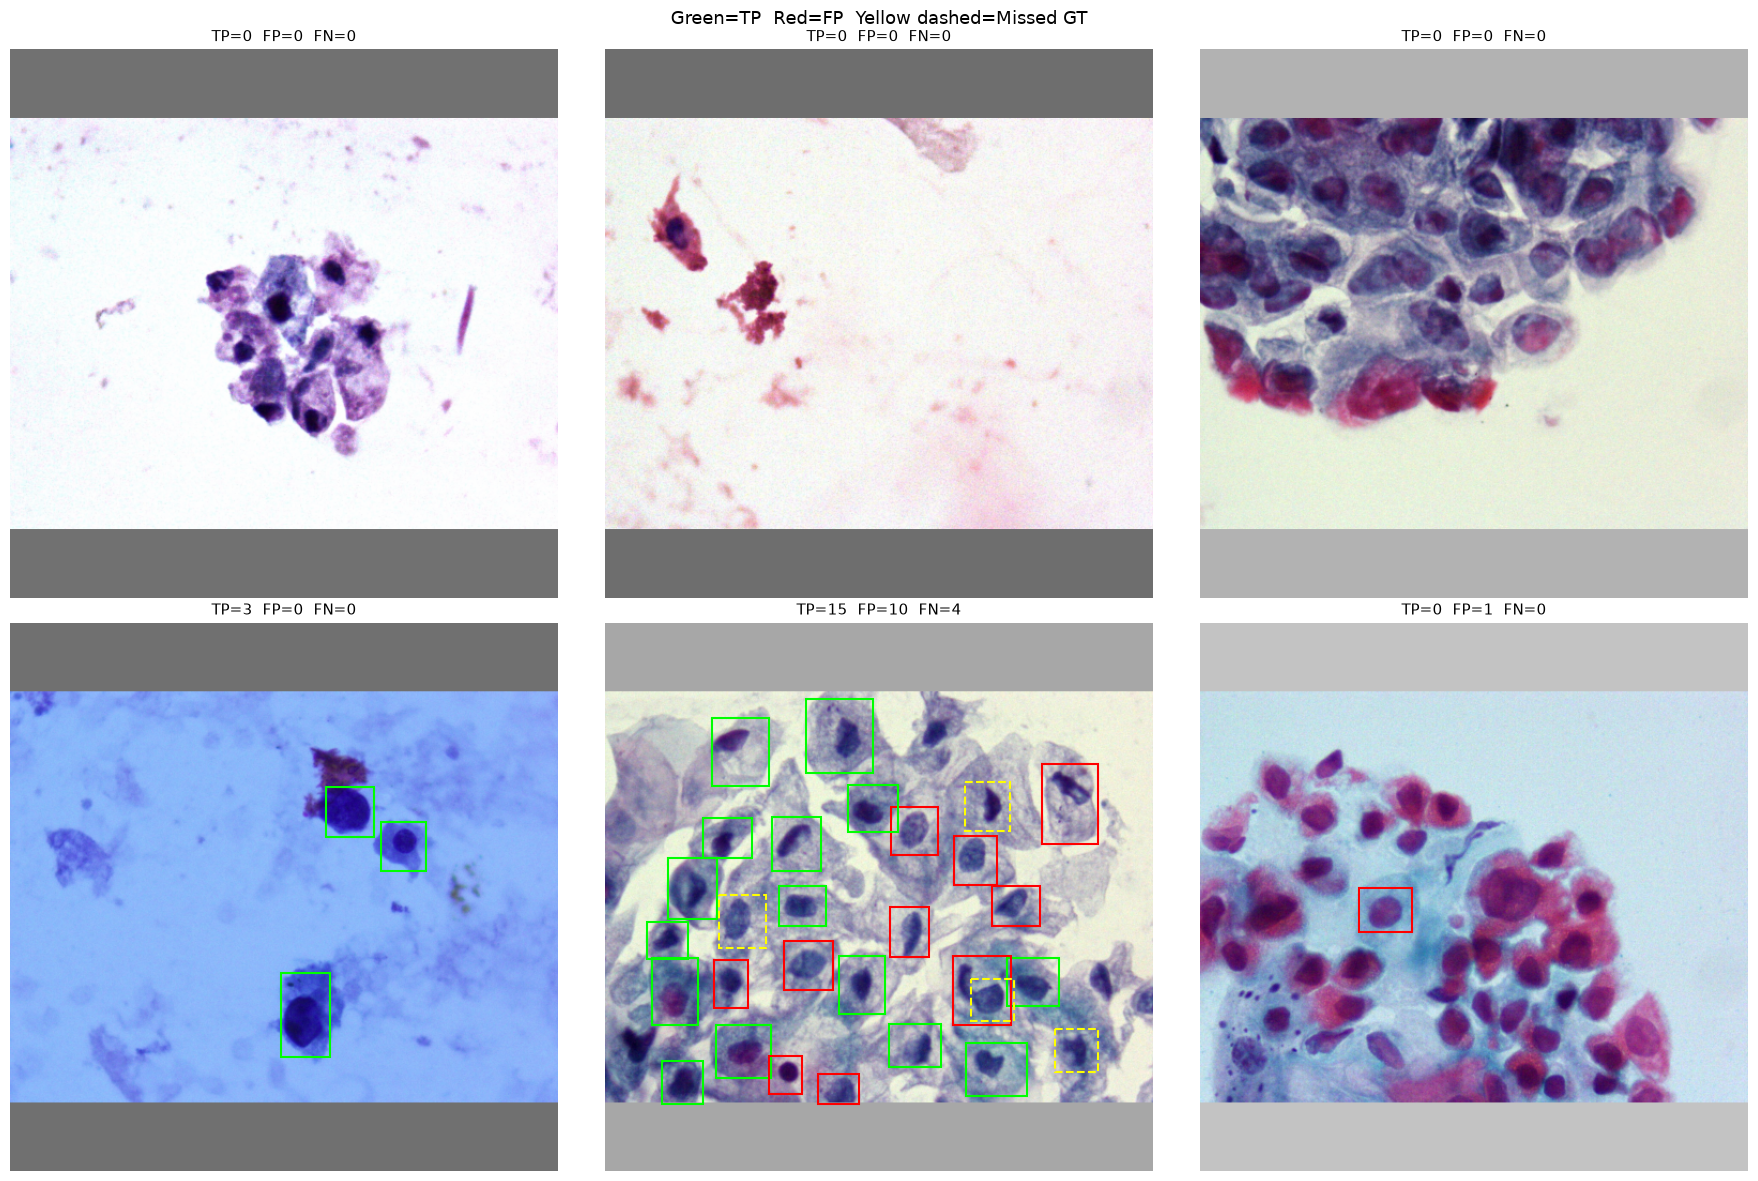


✅ Visualized 6 test images.


In [19]:
# ── Cell 13c: Diagnostic — Visualize False Positives vs. Ground Truth ──────
import matplotlib.pyplot as plt
import matplotlib.patches as patches

N_IMAGES = 6   # how many test images to visualize

model.eval()
shown = 0
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

with torch.no_grad():
    for imgs, targets in test_loader:
        if shown >= N_IMAGES:
            break
        imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]
        with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
            preds = model(imgs_gpu)

        decoded = decode_cornernet(preds,
                                   ae_threshold=1.0,
                                   score_threshold=SCORE_THRESH,
                                   nms_threshold=NMS_THRESH,
                                   input_size=INPUT_SIZE)

        for img_t, det, tgt in zip(imgs, decoded, targets):
            if shown >= N_IMAGES:
                break

            ax = axes[shown]
            img_np = img_t.permute(1, 2, 0).cpu().numpy()
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)
            ax.imshow(img_np)

            gt_boxes = tgt["gt_boxes"]
            det_boxes, det_scores = det["boxes"], det["scores"]

            matched_gt = set()
            if len(det_boxes) > 0 and len(gt_boxes) > 0:
                iou_mat = box_iou_matrix(det_boxes, gt_boxes)
            else:
                iou_mat = None

            # Draw predictions: green=TP, red=FP
            for d_i in range(len(det_boxes)):
                x1, y1, x2, y2 = det_boxes[d_i].tolist()
                is_tp = False
                if iou_mat is not None:
                    best_iou, best_g = iou_mat[d_i].max(dim=0)
                    if best_iou.item() >= 0.5 and best_g.item() not in matched_gt:
                        is_tp = True
                        matched_gt.add(best_g.item())
                color = "lime" if is_tp else "red"
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         linewidth=1.5, edgecolor=color, facecolor="none")
                ax.add_patch(rect)

            # Draw missed GT boxes in yellow (no matching prediction)
            for g_i in range(len(gt_boxes)):
                if g_i not in matched_gt:
                    x1, y1, x2, y2 = gt_boxes[g_i].tolist()
                    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=1.5, edgecolor="yellow",
                                             facecolor="none", linestyle="--")
                    ax.add_patch(rect)

            n_tp = len(matched_gt)
            n_fp = len(det_boxes) - n_tp
            n_fn = len(gt_boxes) - n_tp
            ax.set_title(f"TP={n_tp}  FP={n_fp}  FN={n_fn}", fontsize=11)
            ax.axis("off")
            shown += 1

plt.suptitle("Green=TP  Red=FP  Yellow dashed=Missed GT", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/fp_visualization.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\n✅ Visualized {shown} test images.")

In [20]:
# ── Cell 13d: Diagnostic — FP Best-IoU Distribution ─────────────────────────
# For every false positive, find its best IoU against ANY GT box (not just
# ones that survived the 0.5 threshold and greedy matching). This separates
# "close misses" (box regression issue) from "true unlabeled detections"
# (annotation gap / model over-generalizing beyond labeled morphology).

import numpy as np

model.eval()
fp_best_ious = []       # best IoU each FP has with its nearest GT box (any GT, even if already matched)
fp_records = []         # keep details for inspection

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs_gpu = [img.to(device, non_blocking=True) for img in imgs]
        with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE):
            preds = model(imgs_gpu)

        decoded = decode_cornernet(preds,
                                   ae_threshold=1.0,
                                   score_threshold=SCORE_THRESH,
                                   nms_threshold=NMS_THRESH,
                                   input_size=INPUT_SIZE)

        for det, tgt in zip(decoded, targets):
            gt_boxes = tgt["gt_boxes"]
            det_boxes, det_scores = det["boxes"], det["scores"]
            if len(det_boxes) == 0:
                continue

            if len(gt_boxes) == 0:
                # every detection here is FP with best_iou = 0 (no GT at all)
                for d_i in range(len(det_boxes)):
                    fp_best_ious.append(0.0)
                continue

            iou_mat = box_iou_matrix(det_boxes, gt_boxes)   # [N_det, N_gt]

            # Standard greedy 0.5-threshold matching (same logic as evaluate_on_loader)
            order = det_scores.argsort(descending=True)
            matched_gt = set()
            is_tp = [False] * len(det_boxes)
            for d_i in order.tolist():
                best_iou, best_g = iou_mat[d_i].max(dim=0)
                best_iou, best_g = best_iou.item(), best_g.item()
                if best_iou >= 0.5 and best_g not in matched_gt:
                    is_tp[d_i] = True
                    matched_gt.add(best_g)

            # For every FP, record its best IoU against ANY GT box (ignoring the
            # 0.5 threshold and "already matched" constraint) — this tells us
            # how close it actually came to a real box.
            for d_i in range(len(det_boxes)):
                if not is_tp[d_i]:
                    best_iou_any = iou_mat[d_i].max().item()
                    fp_best_ious.append(best_iou_any)
                    fp_records.append({
                        "best_iou": best_iou_any,
                        "score": det_scores[d_i].item(),
                        "box": det_boxes[d_i].tolist(),
                    })

fp_best_ious = np.array(fp_best_ious)

print(f"Total false positives analyzed: {len(fp_best_ious)}\n")
print("─── Best-IoU distribution of false positives (vs. ANY GT box) ───\n")
bins = [(0.0, 0.05), (0.05, 0.2), (0.2, 0.35), (0.35, 0.5), (0.5, 1.01)]
for lo, hi in bins:
    mask = (fp_best_ious >= lo) & (fp_best_ious < hi)
    n = mask.sum()
    pct = 100 * n / len(fp_best_ious) if len(fp_best_ious) else 0
    label = "no overlap (truly unlabeled region)" if lo == 0.0 else \
            "near-miss, just under 0.5" if hi == 0.5 else \
            f"[{lo:.2f}, {hi:.2f})"
    print(f"  IoU in [{lo:.2f}, {hi:.2f}):  {n:4d} FPs  ({pct:5.1f}%)  — {label}")

print(f"\n  Mean best-IoU across all FPs : {fp_best_ious.mean():.3f}")
print(f"  Median best-IoU across all FPs: {np.median(fp_best_ious):.3f}")

print("\n─── How to read this ───")
print("• Mass concentrated near 0.0       -> FPs sit where NO GT box exists at all")
print("  (annotation gap / model over-generalizing to unlabeled cell types)")
print("• Mass concentrated in 0.35-0.5     -> FPs are CLOSE to a real GT box but just")
print("  miss the threshold (box regression / offset precision issue, fixable by")
print("  tuning offset loss or Gaussian radius, not an annotation problem)")

Total false positives analyzed: 581

─── Best-IoU distribution of false positives (vs. ANY GT box) ───

  IoU in [0.00, 0.05):   533 FPs  ( 91.7%)  — no overlap (truly unlabeled region)
  IoU in [0.05, 0.20):    20 FPs  (  3.4%)  — [0.05, 0.20)
  IoU in [0.20, 0.35):    10 FPs  (  1.7%)  — [0.20, 0.35)
  IoU in [0.35, 0.50):    18 FPs  (  3.1%)  — near-miss, just under 0.5
  IoU in [0.50, 1.01):     0 FPs  (  0.0%)  — [0.50, 1.01)

  Mean best-IoU across all FPs : 0.023
  Median best-IoU across all FPs: 0.000

─── How to read this ───
• Mass concentrated near 0.0       -> FPs sit where NO GT box exists at all
  (annotation gap / model over-generalizing to unlabeled cell types)
• Mass concentrated in 0.35-0.5     -> FPs are CLOSE to a real GT box but just
  miss the threshold (box regression / offset precision issue, fixable by
  tuning offset loss or Gaussian radius, not an annotation problem)


## Cell 14 — Evaluate at Multiple IoU Thresholds

In [21]:
# ── Cell 14: Multi-threshold Evaluation (AP@[0.5, 0.75, 0.5:0.95]) ───────────

iou_thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

print("Computing AP at multiple IoU thresholds on TEST set...")
aps = {}
for iou_t in iou_thresholds:
    m = evaluate_on_loader(
        model, test_loader, device,
        iou_threshold=iou_t,
        score_threshold=SCORE_THRESH,
    )
    aps[iou_t] = m["ap"]
    print(f"   AP@{iou_t:.2f}: {m['ap']:.4f}  |  P={m['precision']:.4f}  R={m['recall']:.4f}")

mAP_50_95 = np.mean(list(aps.values()))
print(f"\n🎯 mAP@0.5:0.95 = {mAP_50_95:.4f}")
print(f"   mAP@0.5      = {aps[0.5]:.4f}")
print(f"   mAP@0.75     = {aps[0.75]:.4f}")

Computing AP at multiple IoU thresholds on TEST set...


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  8.88it/s]


   AP@0.50: 0.7305  |  P=0.5597  R=0.8326


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  9.11it/s]


   AP@0.55: 0.7239  |  P=0.5470  R=0.8167


...

   AP@0.85: 0.0762  |  P=0.1394  R=0.2081


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  8.98it/s]


   AP@0.90: 0.0130  |  P=0.0339  R=0.0509


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  8.94it/s]

   AP@0.95: 0.0005  |  P=0.0007  R=0.0011

🎯 mAP@0.5:0.95 = 0.3971
   mAP@0.5      = 0.7305
   mAP@0.75     = 0.4043


## Cell 15 — GPU Utilisation Check

In [22]:
# ── Cell 15: GPU Utilisation ──────────────────────────────────────────────────
!nvidia-smi

allocated = torch.cuda.memory_allocated(0) / 1e9
reserved  = torch.cuda.memory_reserved(0)  / 1e9
total     = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\n💾 VRAM — Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB | Total: {total:.2f} GB")
print(f"   Utilisation: {reserved/total*100:.1f}%")

Fri Jul  3 08:38:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200 NVL                Off |   00000000:6C:00.0 Off |                    0 |
| N/A   46C    P0            178W /  600W |   19653MiB / 143771MiB |     44%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----